# **LKS Dikmen Kota Malang 2025** | Artificial Intelligence
---

# **I. Data Understanding**

## A. Penjabaran Studi Kasus

### Klasifikasi Diabetes berdasarkan Symptoms

Diberikan suatu dataset yang berisikan berbagai macam fitur, yaitu gejala-gejala umum dari seseorang yang menderita diabetes. Kepala rumah sakit meminta untuk dibuatkan prediksi berupa klasifikasi jika seorang pasien mengidap diabetes atau tidak berdasarkan dataset tersebut.

## B. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## C. Import Dataset

In [2]:
dataset = pd.read_csv("diabetes_data_upload.csv")
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


# **II. Data Preparation**

## A. Exploratory Data Analysis

### 1. Inspeksi Daftar Variabel

In [3]:
dataset.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

### 2. Inspeksi Informasi Ringkas

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

### 3. Inspeksi Statistik Deskiriptif

In [5]:
dataset.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


### 4. Inspeksi Data NaN

In [6]:
dataset.isna().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

### 5. Inspeksi Data Duplicated

In [7]:
dataset.duplicated().sum()

np.int64(269)

### 6. Inspeksi Korelasi

#### a. Dataset Sementara

In [8]:
dataset_korr = dataset.copy()

#### b. Encode pada Dataset Sementara

- encode target

In [9]:
dataset_korr['class'].value_counts()

class
Positive    320
Negative    200
Name: count, dtype: int64

In [10]:
map_target = {'Positive': 1, "Negative" : 0}

In [11]:
dataset_korr['class'] = dataset_korr['class'].map(map_target)

In [12]:
dataset_korr['class'].value_counts()

class
1    320
0    200
Name: count, dtype: int64

- encode fitur

- pengecekan value

- gender

In [13]:
dataset_korr['Gender'].value_counts()

Gender
Male      328
Female    192
Name: count, dtype: int64

- Polyuria

In [14]:
dataset_korr['Polyuria'].value_counts()

Polyuria
No     262
Yes    258
Name: count, dtype: int64

- Polydipsia

In [15]:
dataset_korr['Polydipsia'].value_counts()

Polydipsia
No     287
Yes    233
Name: count, dtype: int64

- weight loss

In [16]:
dataset_korr['sudden weight loss'].value_counts()

sudden weight loss
No     303
Yes    217
Name: count, dtype: int64

- weakness

In [17]:
dataset_korr['weakness'].value_counts()

weakness
Yes    305
No     215
Name: count, dtype: int64

- Polyphagia

In [18]:
dataset_korr['Polyphagia'].value_counts()

Polyphagia
No     283
Yes    237
Name: count, dtype: int64

- Genital

In [19]:
dataset_korr['Genital thrush'].value_counts()

Genital thrush
No     404
Yes    116
Name: count, dtype: int64

- Visual

In [20]:
dataset_korr['visual blurring'].value_counts()

visual blurring
No     287
Yes    233
Name: count, dtype: int64

- Itching

In [21]:
dataset_korr['Itching'].value_counts()

Itching
No     267
Yes    253
Name: count, dtype: int64

- Irritability

In [22]:
dataset_korr['Irritability'].value_counts()

Irritability
No     394
Yes    126
Name: count, dtype: int64

- delayed healing

In [23]:
dataset_korr['delayed healing'].value_counts()

delayed healing
No     281
Yes    239
Name: count, dtype: int64

- partial

In [24]:
dataset_korr['partial paresis'].value_counts()

partial paresis
No     296
Yes    224
Name: count, dtype: int64

- muscle 

In [25]:
dataset_korr['muscle stiffness'].value_counts()

muscle stiffness
No     325
Yes    195
Name: count, dtype: int64

- alopecia

In [26]:
dataset_korr['Alopecia'].value_counts()

Alopecia
No     341
Yes    179
Name: count, dtype: int64

- obesity

In [27]:
dataset_korr['Obesity'].value_counts()

Obesity
No     432
Yes     88
Name: count, dtype: int64

- fungsi encode method factorize

In [28]:
col_to_pd = dataset.drop(columns=["weakness", "class"])
for col in col_to_pd:
    dataset_korr[col] = pd.factorize(dataset_korr[col])[0]

- encode weakness

In [29]:
dataset_korr['weakness'].value_counts()

weakness
Yes    305
No     215
Name: count, dtype: int64

In [30]:
map_weakness = {"Yes": 1, "No": 0}

In [31]:
dataset_korr['weakness'] = dataset_korr['weakness'].map(map_weakness)

In [32]:
dataset_korr['weakness'].value_counts()

weakness
1    305
0    215
Name: count, dtype: int64

- gender

In [33]:
dataset_korr['Gender'].value_counts()

Gender
0    328
1    192
Name: count, dtype: int64

- Polyuria

In [34]:
dataset_korr['Polyuria'].value_counts()

Polyuria
0    262
1    258
Name: count, dtype: int64

- Polydipsia

In [35]:
dataset_korr['Polydipsia'].value_counts()

Polydipsia
1    287
0    233
Name: count, dtype: int64

- weight loss

In [36]:
dataset_korr['sudden weight loss'].value_counts()

sudden weight loss
0    303
1    217
Name: count, dtype: int64

- weakness

In [37]:
dataset_korr['weakness'].value_counts()

weakness
1    305
0    215
Name: count, dtype: int64

- Polyphagia

In [38]:
dataset_korr['Polyphagia'].value_counts()

Polyphagia
0    283
1    237
Name: count, dtype: int64

- Genital

In [39]:
dataset_korr['Genital thrush'].value_counts()

Genital thrush
0    404
1    116
Name: count, dtype: int64

- Visual

In [40]:
dataset_korr['visual blurring'].value_counts()

visual blurring
0    287
1    233
Name: count, dtype: int64

- Itching

In [41]:
dataset_korr['Itching'].value_counts()

Itching
1    267
0    253
Name: count, dtype: int64

- Irritability

In [42]:
dataset_korr['Irritability'].value_counts()

Irritability
0    394
1    126
Name: count, dtype: int64

- delayed healing

In [43]:
dataset_korr['delayed healing'].value_counts()

delayed healing
1    281
0    239
Name: count, dtype: int64

- partial

In [44]:
dataset_korr['partial paresis'].value_counts()

partial paresis
0    296
1    224
Name: count, dtype: int64

- muscle 

In [45]:
dataset_korr['muscle stiffness'].value_counts()

muscle stiffness
1    325
0    195
Name: count, dtype: int64

- alopecia

In [46]:
dataset_korr['Alopecia'].value_counts()

Alopecia
1    341
0    179
Name: count, dtype: int64

- obesity

In [47]:
dataset_korr['Obesity'].value_counts()

Obesity
1    432
0     88
Name: count, dtype: int64

#### c. Inspeksi Tipe Data Ulang

In [48]:
dataset_korr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    int64
 2   Polyuria            520 non-null    int64
 3   Polydipsia          520 non-null    int64
 4   sudden weight loss  520 non-null    int64
 5   weakness            520 non-null    int64
 6   Polyphagia          520 non-null    int64
 7   Genital thrush      520 non-null    int64
 8   visual blurring     520 non-null    int64
 9   Itching             520 non-null    int64
 10  Irritability        520 non-null    int64
 11  delayed healing     520 non-null    int64
 12  partial paresis     520 non-null    int64
 13  muscle stiffness    520 non-null    int64
 14  Alopecia            520 non-null    int64
 15  Obesity             520 non-null    int64
 16  class               520 non-null    int64
dt

#### d. Korelasi Antar Variabel

<Axes: >

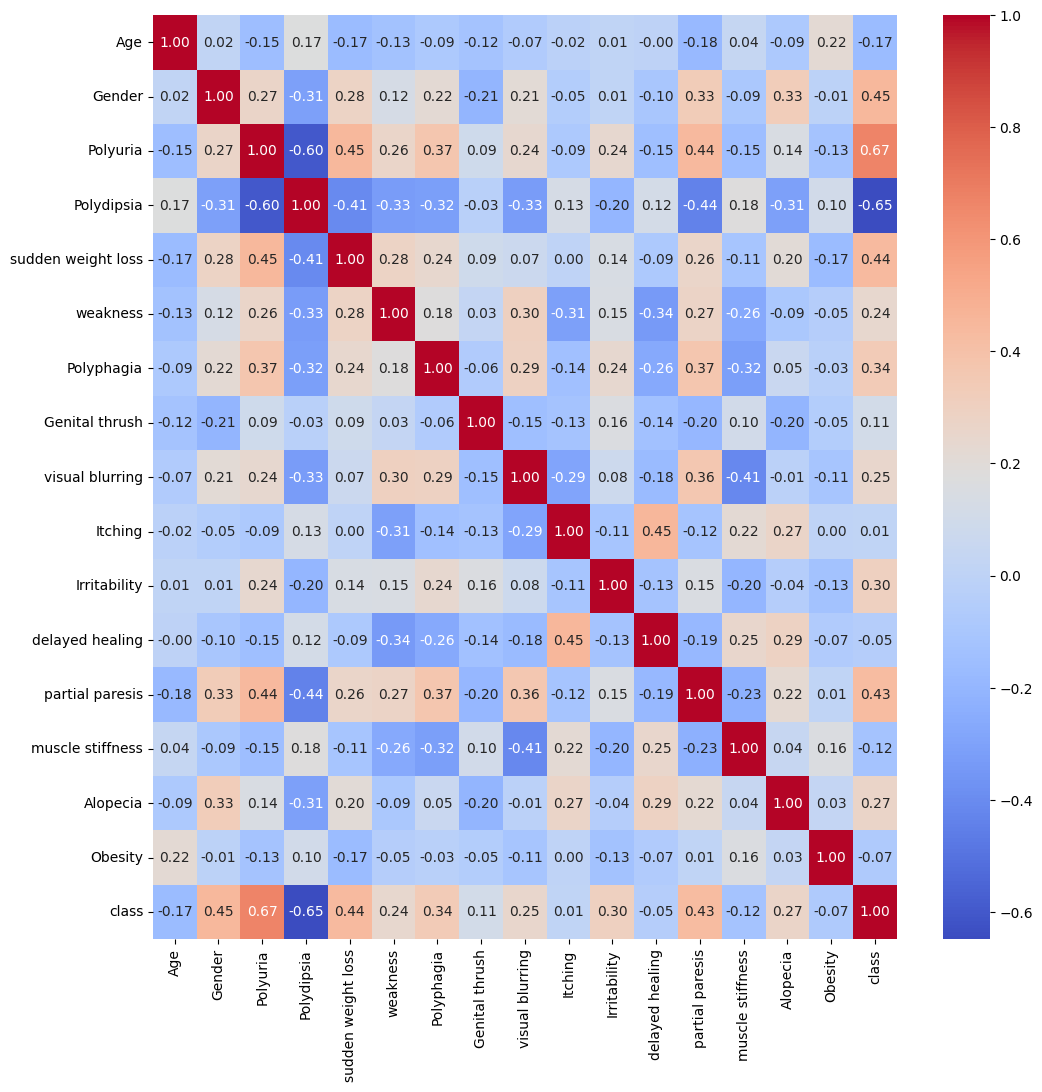

In [49]:
plt.figure(figsize = (12, 12))
sns.heatmap(dataset_korr.corr(), cmap = 'coolwarm', fmt=".2f", annot=True)

### 7. Inspeksi Distribusi Kelas Target

In [50]:
target_count = dataset['class'].value_counts()
target_count

class
Positive    320
Negative    200
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1e7966aade0>,
 [Text(-0.3787794905472502, -1.0858296816447621, 'Positive'),
  Text(0.37877913673901087, 1.0858298050667288, 'Negative')],
 [Text(-0.21409275552670665, -0.6137298200600829, '61.5%'),
  Text(0.21409255554813658, 0.6137298898203247, '38.5%')])

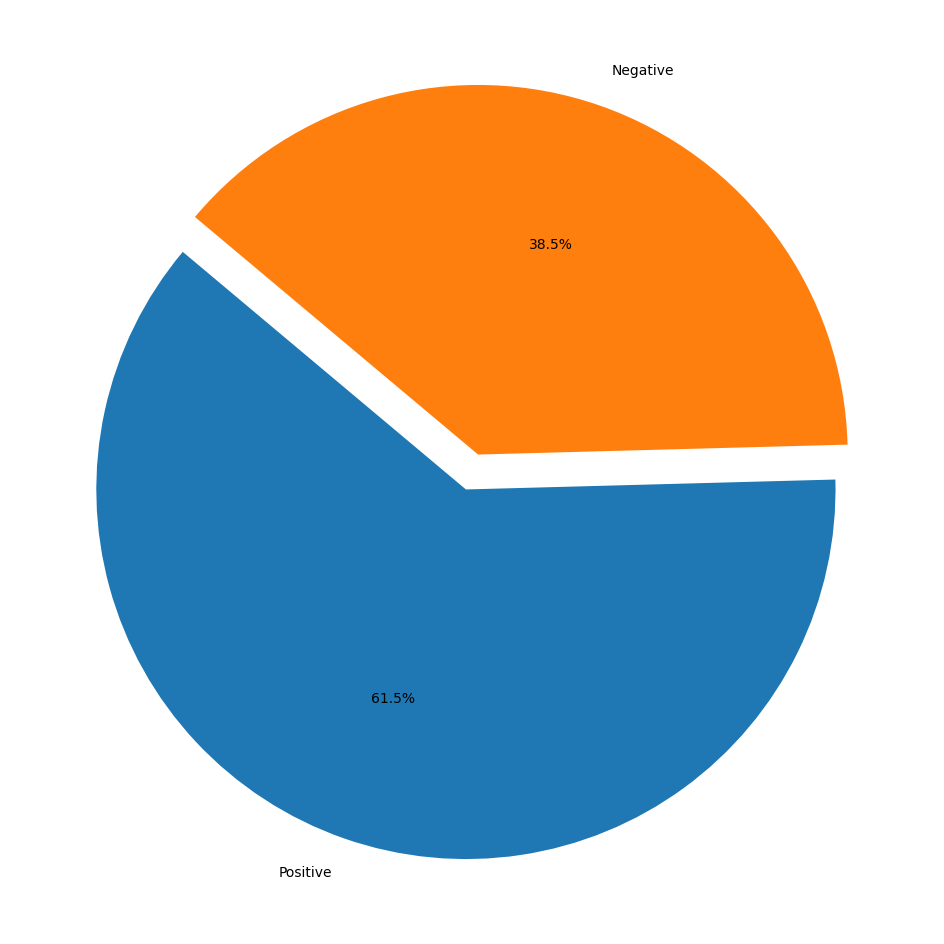

In [51]:
color = plt.get_cmap('tab10').colors
explode = [0.05] * len(target_count)
plt.figure(figsize=(12, 12))

plt.pie(
    target_count,
    explode=explode,
    labels = target_count.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=color
)

### 8. Inspeksi Data Outlier

In [52]:
plt.figure(figsize = (12, 12))
sns.boxplot(dataset_korr)

<Axes: >

Error in callback <function flush_figures at 0x000001E7FFDEE020> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

### 9. Inspeksi Distribusi Data

In [ ]:
# sns.pairplot(dataset_korr)

## B. Feature Selection

In [ ]:
feature_cols = ["Polyuria", "Gender", "sudden weight loss", "partial paresis"]

## C. Data Cleaning

### 1. Data Duplicated

In [ ]:
dataset = dataset.drop_duplicates()

In [ ]:
dataset.duplicated().sum()

np.int64(0)

## D. Encoding Data

In [ ]:
col_to_pd = dataset[feature_cols]
for col in col_to_pd:
    dataset[col] = pd.factorize(dataset[col])[0]

map_target = {'Positive': 1, "Negative" : 0}
dataset['class'] = dataset['class'].map(map_target)

C:\Users\nizam\AppData\Local\Temp\ipykernel_13300\1128735678.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[col] = pd.factorize(dataset[col])[0]
C:\Users\nizam\AppData\Local\Temp\ipykernel_13300\1128735678.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[col] = pd.factorize(dataset[col])[0]
C:\Users\nizam\AppData\Local\Temp\ipykernel_13300\1128735678.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [ ]:
dataset['class'].value_counts()

class
1    173
0     78
Name: count, dtype: int64

## E. Splitting Dataset

In [ ]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "class")

## F. Feature Target Declaration

In [ ]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()

y_train = dataset_training["class"].to_numpy()
y_test = dataset_testing["class"].to_numpy()

# **III. Modeling**

## A. Model Application

### 1. Model dengan Class

In [ ]:
class TreeEnsemble:
    def __init__(self, max_depth=5, feature_names=feature_cols, mode="single", n_trees=10, sample_ratio=0.8, feature_ratio=0.8):
        self.max_depth = max_depth
        self.mode = mode
        self.feature_names = feature_names
        self.n_trees = n_trees
        self.sample_ratio = sample_ratio
        self.feature_ratio = feature_ratio
        self.trees = [] if self.mode == "ensemble" else None

    def most_common_value(self, arr):
        unique, counts = np.unique(arr, return_counts=True)
        return unique[np.argmax(counts)]
    
    def entropy(self, y):
        unique, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs * 1e-9))
    
    def information_gain(self, parent, left, right):
        return self.entropy(parent) - (len(left) / len(parent) * self.entropy(left) + len(right) / len(parent) * self.entropy(right))
    
    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 0:
            return self.most_common_value(y)
        
        best_feature, best_split, best_gain = None, None, -1
        for feature in range(X.shape[1]):
            unique_values = np.unique(X[:, feature])
            for value in unique_values:
                left_mask = X[:, feature] <= value
                right_mask = X[:, feature] > value

                if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                    continue

                gain = self.information_gain(y, y[left_mask], y[right_mask])
                if gain > best_gain:
                    best_feature, best_split, best_gain = feature, value, gain

        if best_gain == -1:
            return self.most_common_value(y)
        
        left_mask = X[:, best_feature] <= best_split
        right_mask = X[:, best_feature] > best_split

        return {
            "feature": best_feature,
            "split": best_split,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }
    
    def fit(self, X, y):
        if self.mode == "single":
            self.trees = self._build_tree(X, y)

        else:
            self.trees = []
            n_samples = int(len(X) * self.sample_ratio)
            n_features = int(X.shape[1] * self.feature_ratio)

            for _ in range(self.n_trees):
                sample_idx = np.random.choice(len(X), n_samples, replace=True)
                feature_idx = np.random.choice(X.shape[1], n_features, replace=False)
                X_sample, y_sample = X[sample_idx][:, feature_idx], y[sample_idx]
                tree = self._build_tree(X_sample, y_sample)
                self.trees.append((tree, feature_idx))

    def _predict_sample(self, tree, sample):
        if not isinstance(tree, dict):
            return tree
        
        feature = tree["feature"]
        split = tree["split"]

        if sample[feature] <= split:
            return self._predict_sample(tree["left"], sample)
        else:
            return self._predict_sample(tree["right"], sample)
        
    def predict(self, X):
        if self.mode == "single":
            return np.array([self._predict_sample(self.trees, sample) for sample in X])
        
        predictions = []
        for tree, feature_idx in self.trees:
            preds = [self._predict_sample(tree, sample[feature_idx]) for sample in X]
            predictions.append(preds)

        predictions = np.array(predictions)
        final_preds = [np.bincount(predictions[:, i]).argmax() for i in range(predictions.shape[1])]
        return np.array(final_preds)
        
    def print_tree(self, tree = None, depth = 0):
        if tree is None:
            tree = self.trees if self.mode == 'single' else self.trees[0][0]
        
        if not isinstance(tree, dict):
            print("  " * depth + f"Predict: {tree}")
            return 
        
        feature_name = self.feature_names[tree['feature']] if self.feature_names else f"{tree['feature']}"
        print("  " * depth + f"({feature_name}) <= {tree['split']}")

        print("  " * depth + "-> Left:")
        self.print_tree(tree['left'], depth + 1)

        print("  " * depth + "-> Right:")
        self.print_tree(tree['right'], depth + 1)
        
    def plot_tree(self, tree = None, x = 0.5, y = 1, dx = 0.25, dy = 0.15 , ax = None):

        if ax is None:
            fig, ax = plt.subplots(figsize = (30, 40))

        ax.axis("off")
        
        if tree is None:
            tree = self.trees if self.mode == 'single' else self.trees[0][0]
        

        def _plot_node(tree, x, y, dx, dy):

            if not isinstance(tree, dict):
                ax.text(x, y, f'{tree}', bbox = dict(facecolor = "lightblue", alpha = 0.5), ha = 'center', va = "center")
                return tree

            feature_name = self.feature_names[tree['feature']] if self.feature_names else f"{tree['feature']}"
            ax.text(x, y, f"{feature_name} <= {tree['split']}", bbox = dict(facecolor = "lightblue", alpha = 0.5), ha = 'center', va = "center")

            x_left, x_right = x - dx, x + dx
            y_next = y - dy

            ax.plot([x, x_left], [y, y_next], 'k-')
            ax.plot([x, x_right], [y, y_next], 'k-')

            ax.text((x + x_left)/2, (y + y_next)/2, "True", color = 'green',fontsize = 13)
            ax.text((x + x_right)/2, (y + y_next)/2, "False", color = 'red',fontsize = 13)

            _plot_node(tree['left'], x_left, y_next, dx/2, dy)
            _plot_node(tree['right'], x_right, y_next, dx/2, dy)

        _plot_node(tree, x, y, dx, dy)

    def plot_forest(self, num_trees):
        num_trees = min(num_trees, len(self.trees))

        for i in range(num_trees):

            tree, _ = self.trees[i]
            fig, ax = plt.subplots(figsize = (30,40))
            self.plot_tree(tree, ax = ax)
            plt.title(f"Tree: {i + 1}")
            plt.show()

    def trace_decision_path(self, tree, sample, depth = 0):
        if not isinstance(tree, dict):
            print("  " * depth + f"==> Predict: {tree}")
            return tree
        
        split = tree['split']
        feature = tree['feature']
        decision = "Left" if sample[feature] <= split else "Right"

        print("  " * depth + f"{self.feature_names[feature] if self.feature_names else f'(Feature: {feature})'} <= {split} {decision}")
        next_branch = tree['left'] if sample[feature] <= split else tree['right']

        return self.trace_decision_path(next_branch, sample, depth + 1)

    def predict_with_trace(self, X):
        predictions = []

        for i, sample in enumerate(X):
            print(f"\nSample: {i + 1}")
            
            if self.mode == 'single':
                pred = self.trace_decision_path(self.trees, sample)
            
            else:
                tree_pred = []
                for j, (tree, feature_idx) in enumerate(self.trees):
                    print(f"\nTree: {j + 1}")
                    reduced_sample = np.array(sample)[feature_idx]
                    tree_pred.append(self.trace_decision_path(tree ,reduced_sample))

                pred = np.bincount(tree_pred).argmax()
                print(f"Majority Vote: {pred}")
            
            predictions.append(pred)

        return np.array(predictions)

### 2. Menjalankan Mode Single

In [ ]:
model_tree = TreeEnsemble(mode="single", max_depth=7)
model_tree.fit(X_train, y_train)

y_pred_tree_train = model_tree.predict(X_train)
y_pred_tree_test = model_tree.predict(X_test)

### 3. Menjalankan Mode Ensemble

In [ ]:
model_forest = TreeEnsemble(mode="ensemble", max_depth=5, n_trees=10)
model_forest.fit(X_train, y_train)

y_pred_forest_train = model_forest.predict(X_train)
y_pred_forest_test = model_forest.predict(X_test)

## B. Hasil Prediksi

In [ ]:
ytrain = pd.Series(y_train)
ytrain.value_counts()

1    138
0     62
Name: count, dtype: int64

In [ ]:
ytes = pd.Series(y_test)
ytes.value_counts()

1    35
0    16
Name: count, dtype: int64

### 1. Decision Tree

In [ ]:
y_pred_tree_test

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1])

In [ ]:
y1 = pd.Series(y_pred_tree_test)
y1.value_counts()

1    29
0    22
Name: count, dtype: int64

In [ ]:
y_pred_tree_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0])

In [ ]:
y2 = pd.Series(y_pred_tree_train)
y2.value_counts()

1    126
0     74
Name: count, dtype: int64

### 2. Random Forest

In [ ]:
y_pred_forest_test

array([0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1])

In [ ]:
y3 = pd.Series(y_pred_forest_test)
y3.value_counts()

1    30
0    21
Name: count, dtype: int64

In [ ]:
y_pred_forest_train

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0])

In [ ]:
y4 = pd.Series(y_pred_forest_train)
y4.value_counts()

1    129
0     71
Name: count, dtype: int64

## C. Visualisasi Model

### 1. Hierarki Decision Tree

In [ ]:
model_tree.print_tree()

(Polyuria) <= 0
-> Left:
  (sudden weight loss) <= 0
  -> Left:
    (Gender) <= 0
    -> Left:
      (partial paresis) <= 0
      -> Left:
        Predict: 0
      -> Right:
        Predict: 0
    -> Right:
      (partial paresis) <= 0
      -> Left:
        Predict: 0
      -> Right:
        Predict: 1
  -> Right:
    (Gender) <= 0
    -> Left:
      (partial paresis) <= 0
      -> Left:
        Predict: 0
      -> Right:
        Predict: 1
    -> Right:
      (partial paresis) <= 0
      -> Left:
        Predict: 1
      -> Right:
        Predict: 1
-> Right:
  (Gender) <= 0
  -> Left:
    (sudden weight loss) <= 0
    -> Left:
      (partial paresis) <= 0
      -> Left:
        Predict: 1
      -> Right:
        Predict: 1
    -> Right:
      (partial paresis) <= 0
      -> Left:
        Predict: 1
      -> Right:
        Predict: 1
  -> Right:
    (sudden weight loss) <= 0
    -> Left:
      (partial paresis) <= 0
      -> Left:
        Predict: 1
      -> Right:
        Predict: 1

### 2. Visualisasi Pohon Single

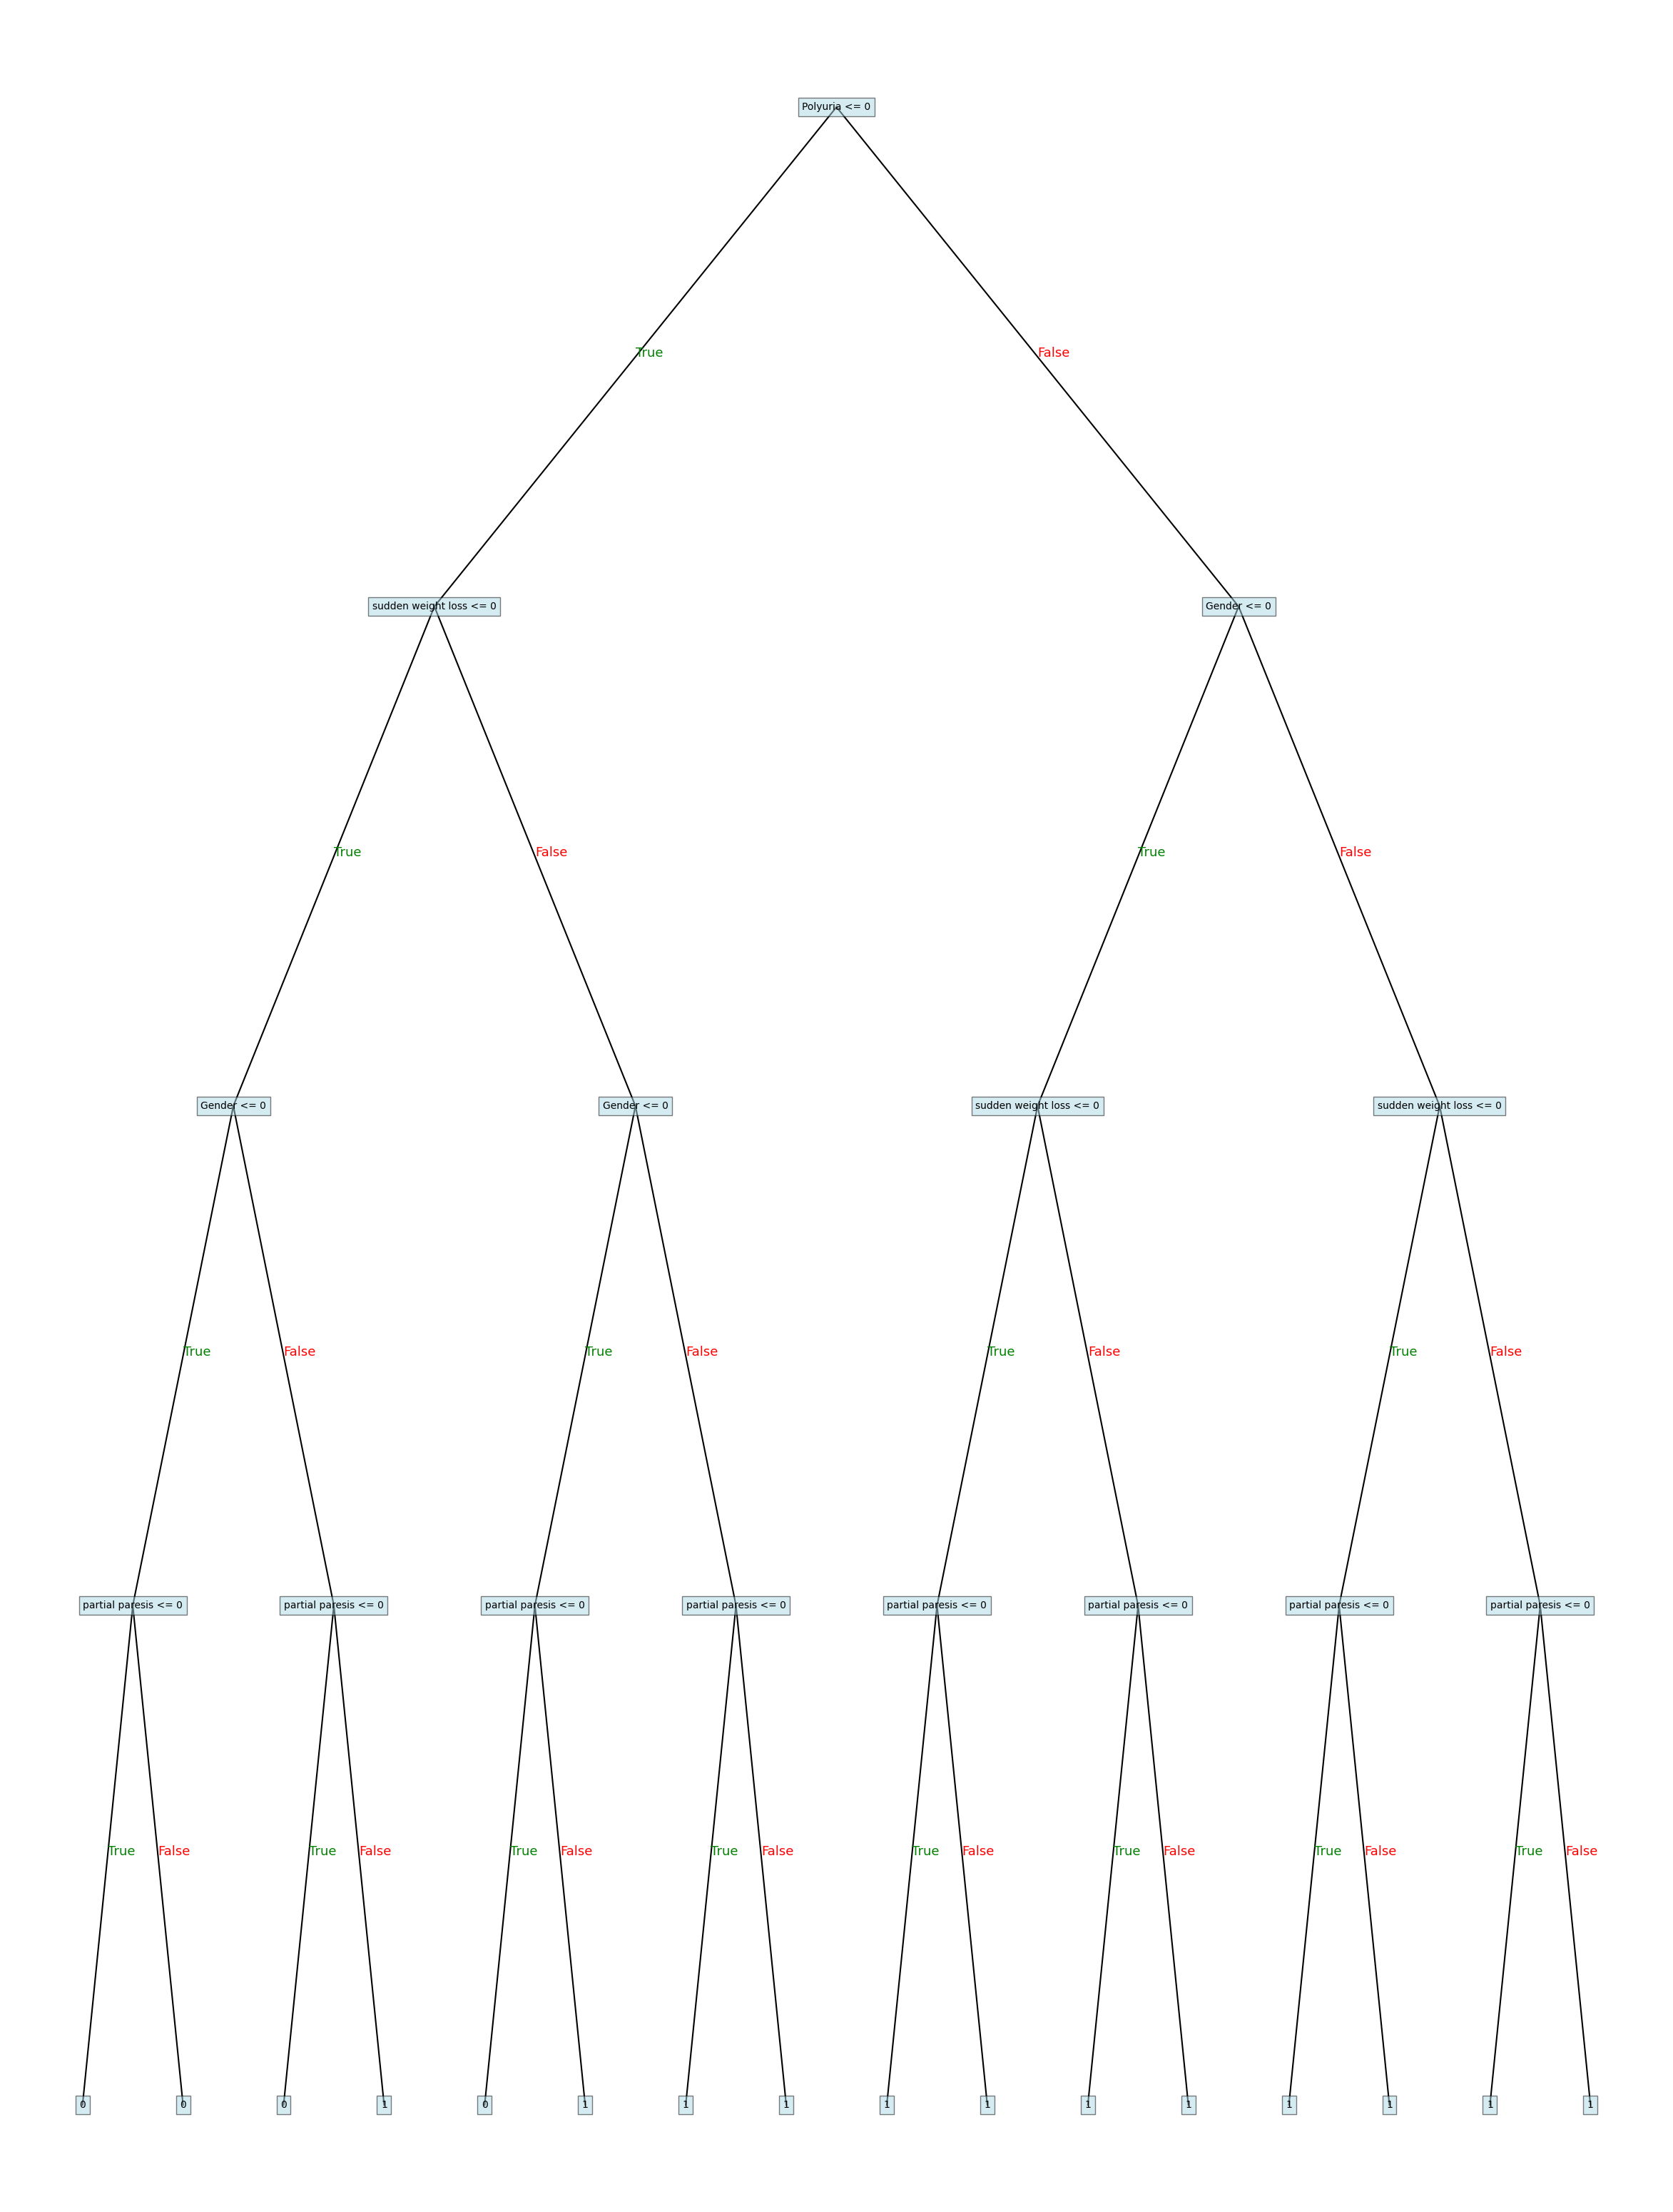

In [ ]:
model_tree.plot_tree()

### 3. Visualisasi Pohon Ensemble

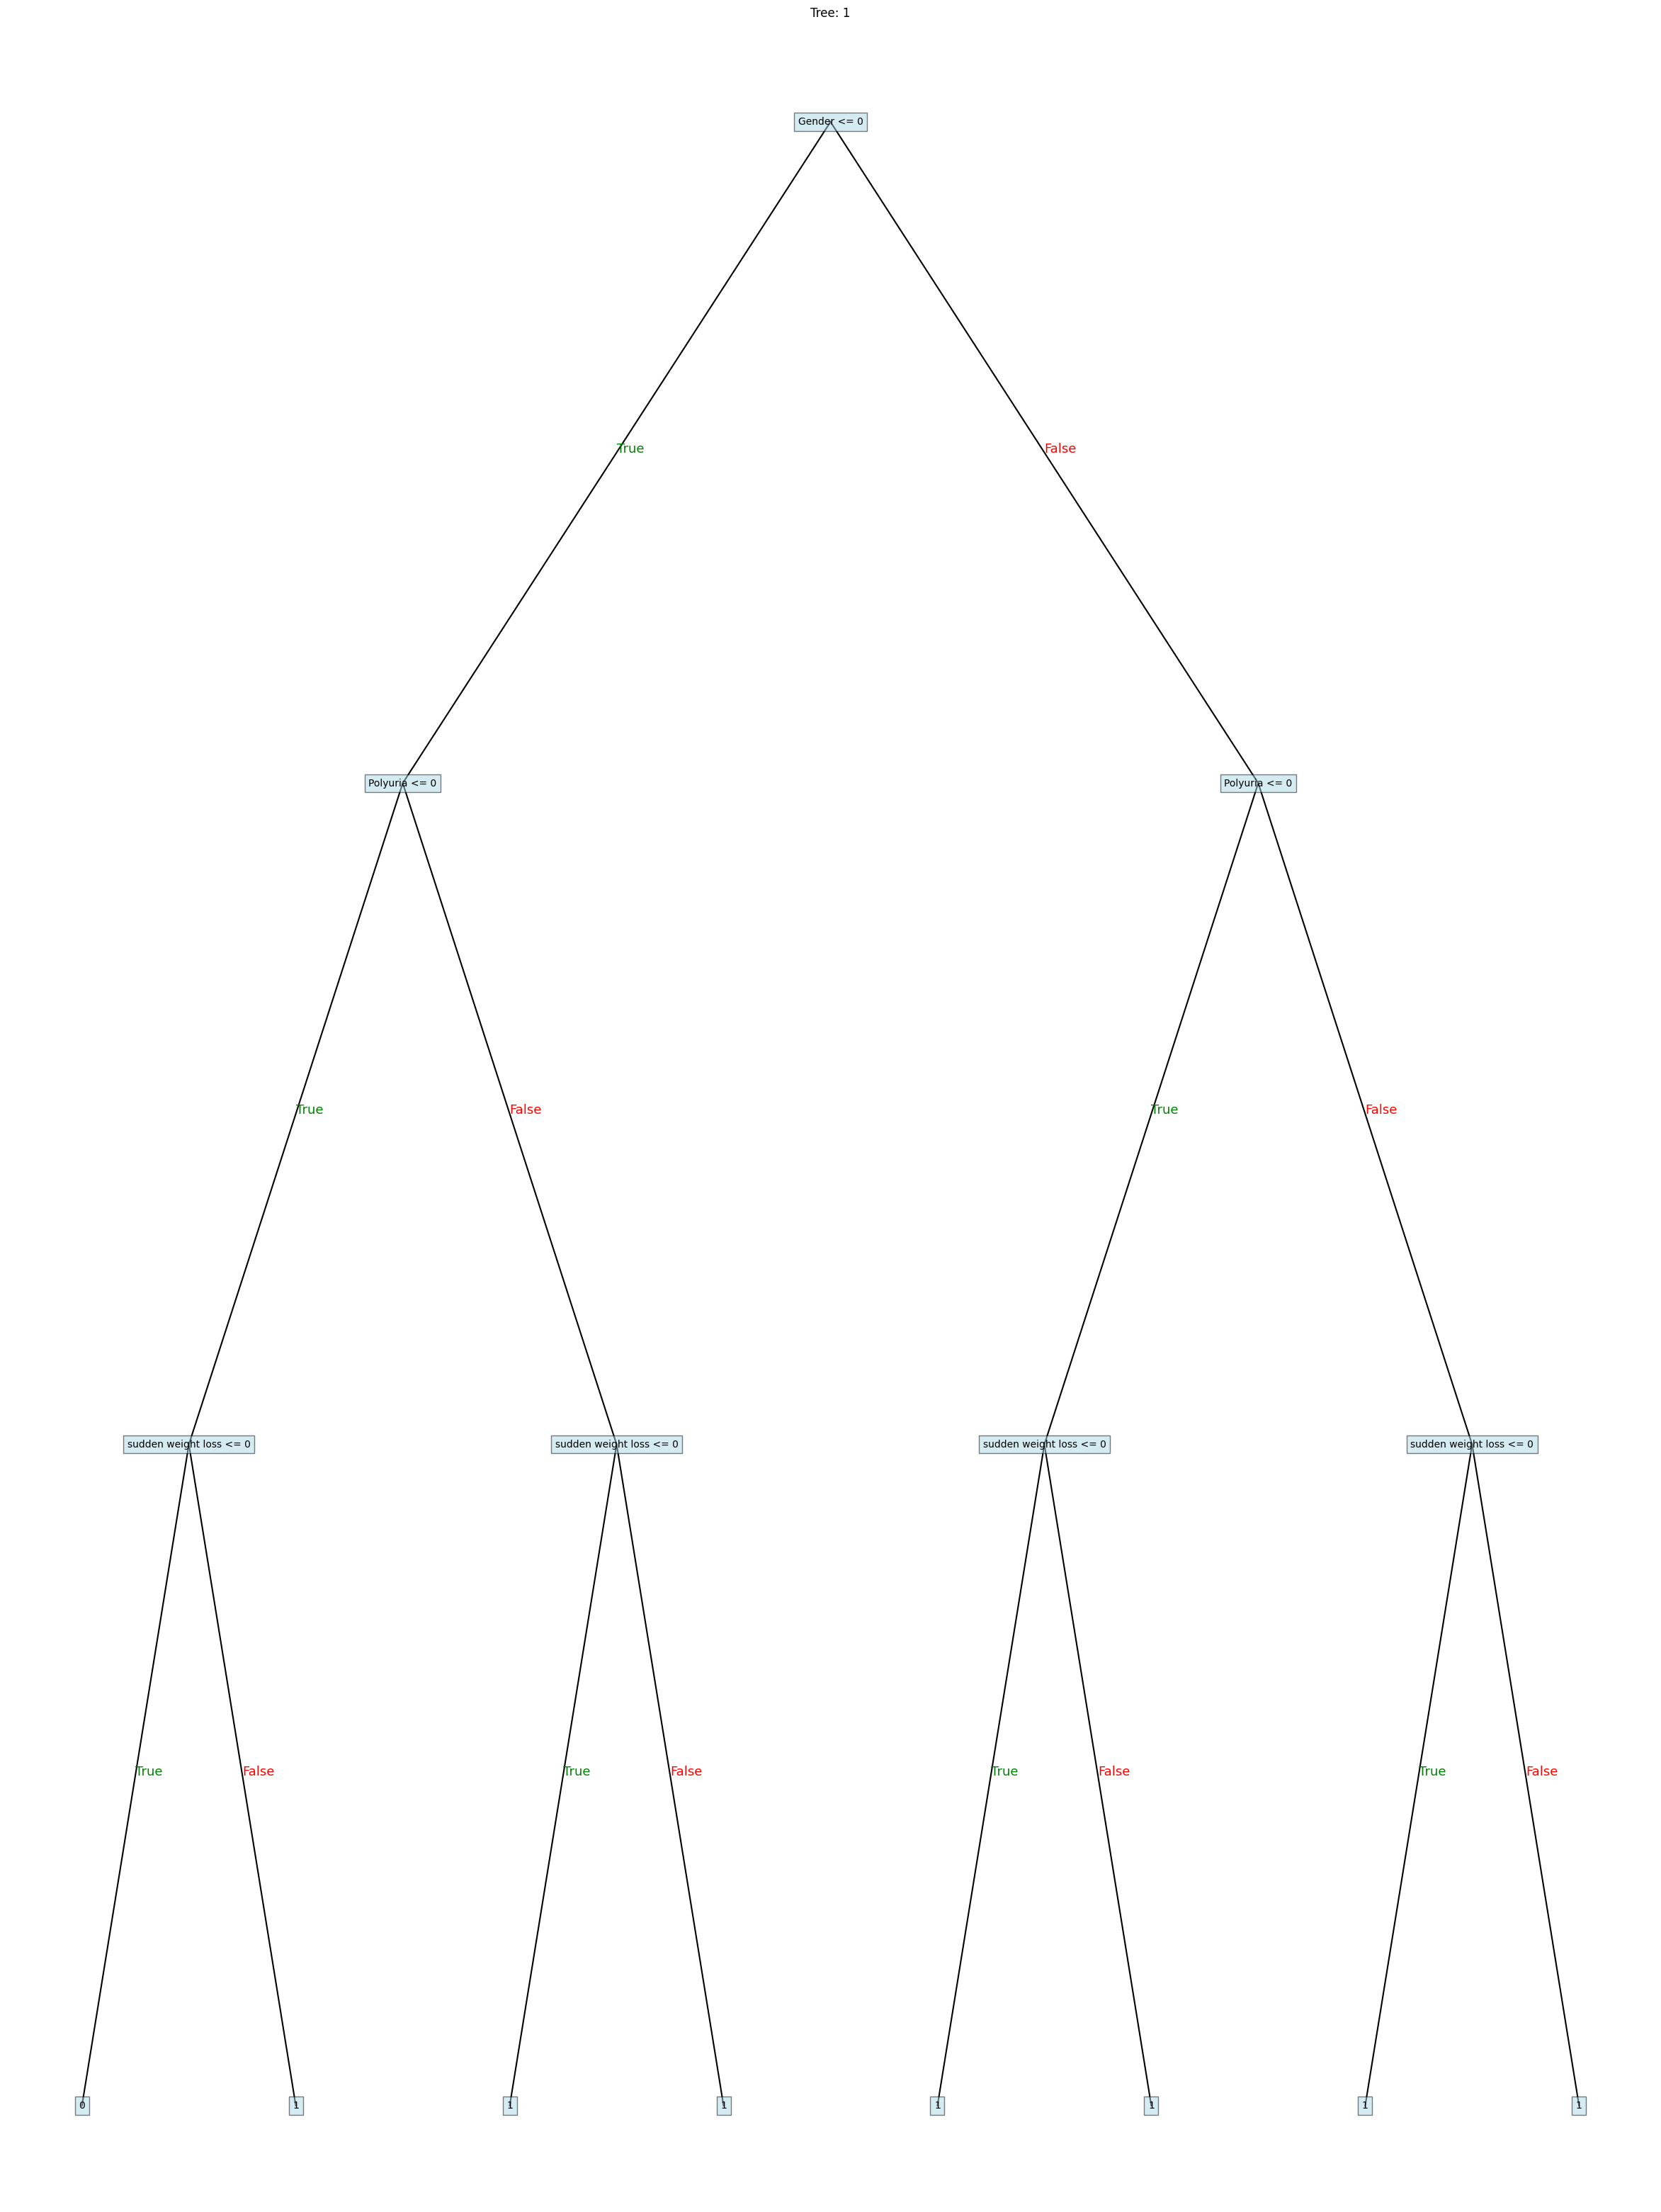

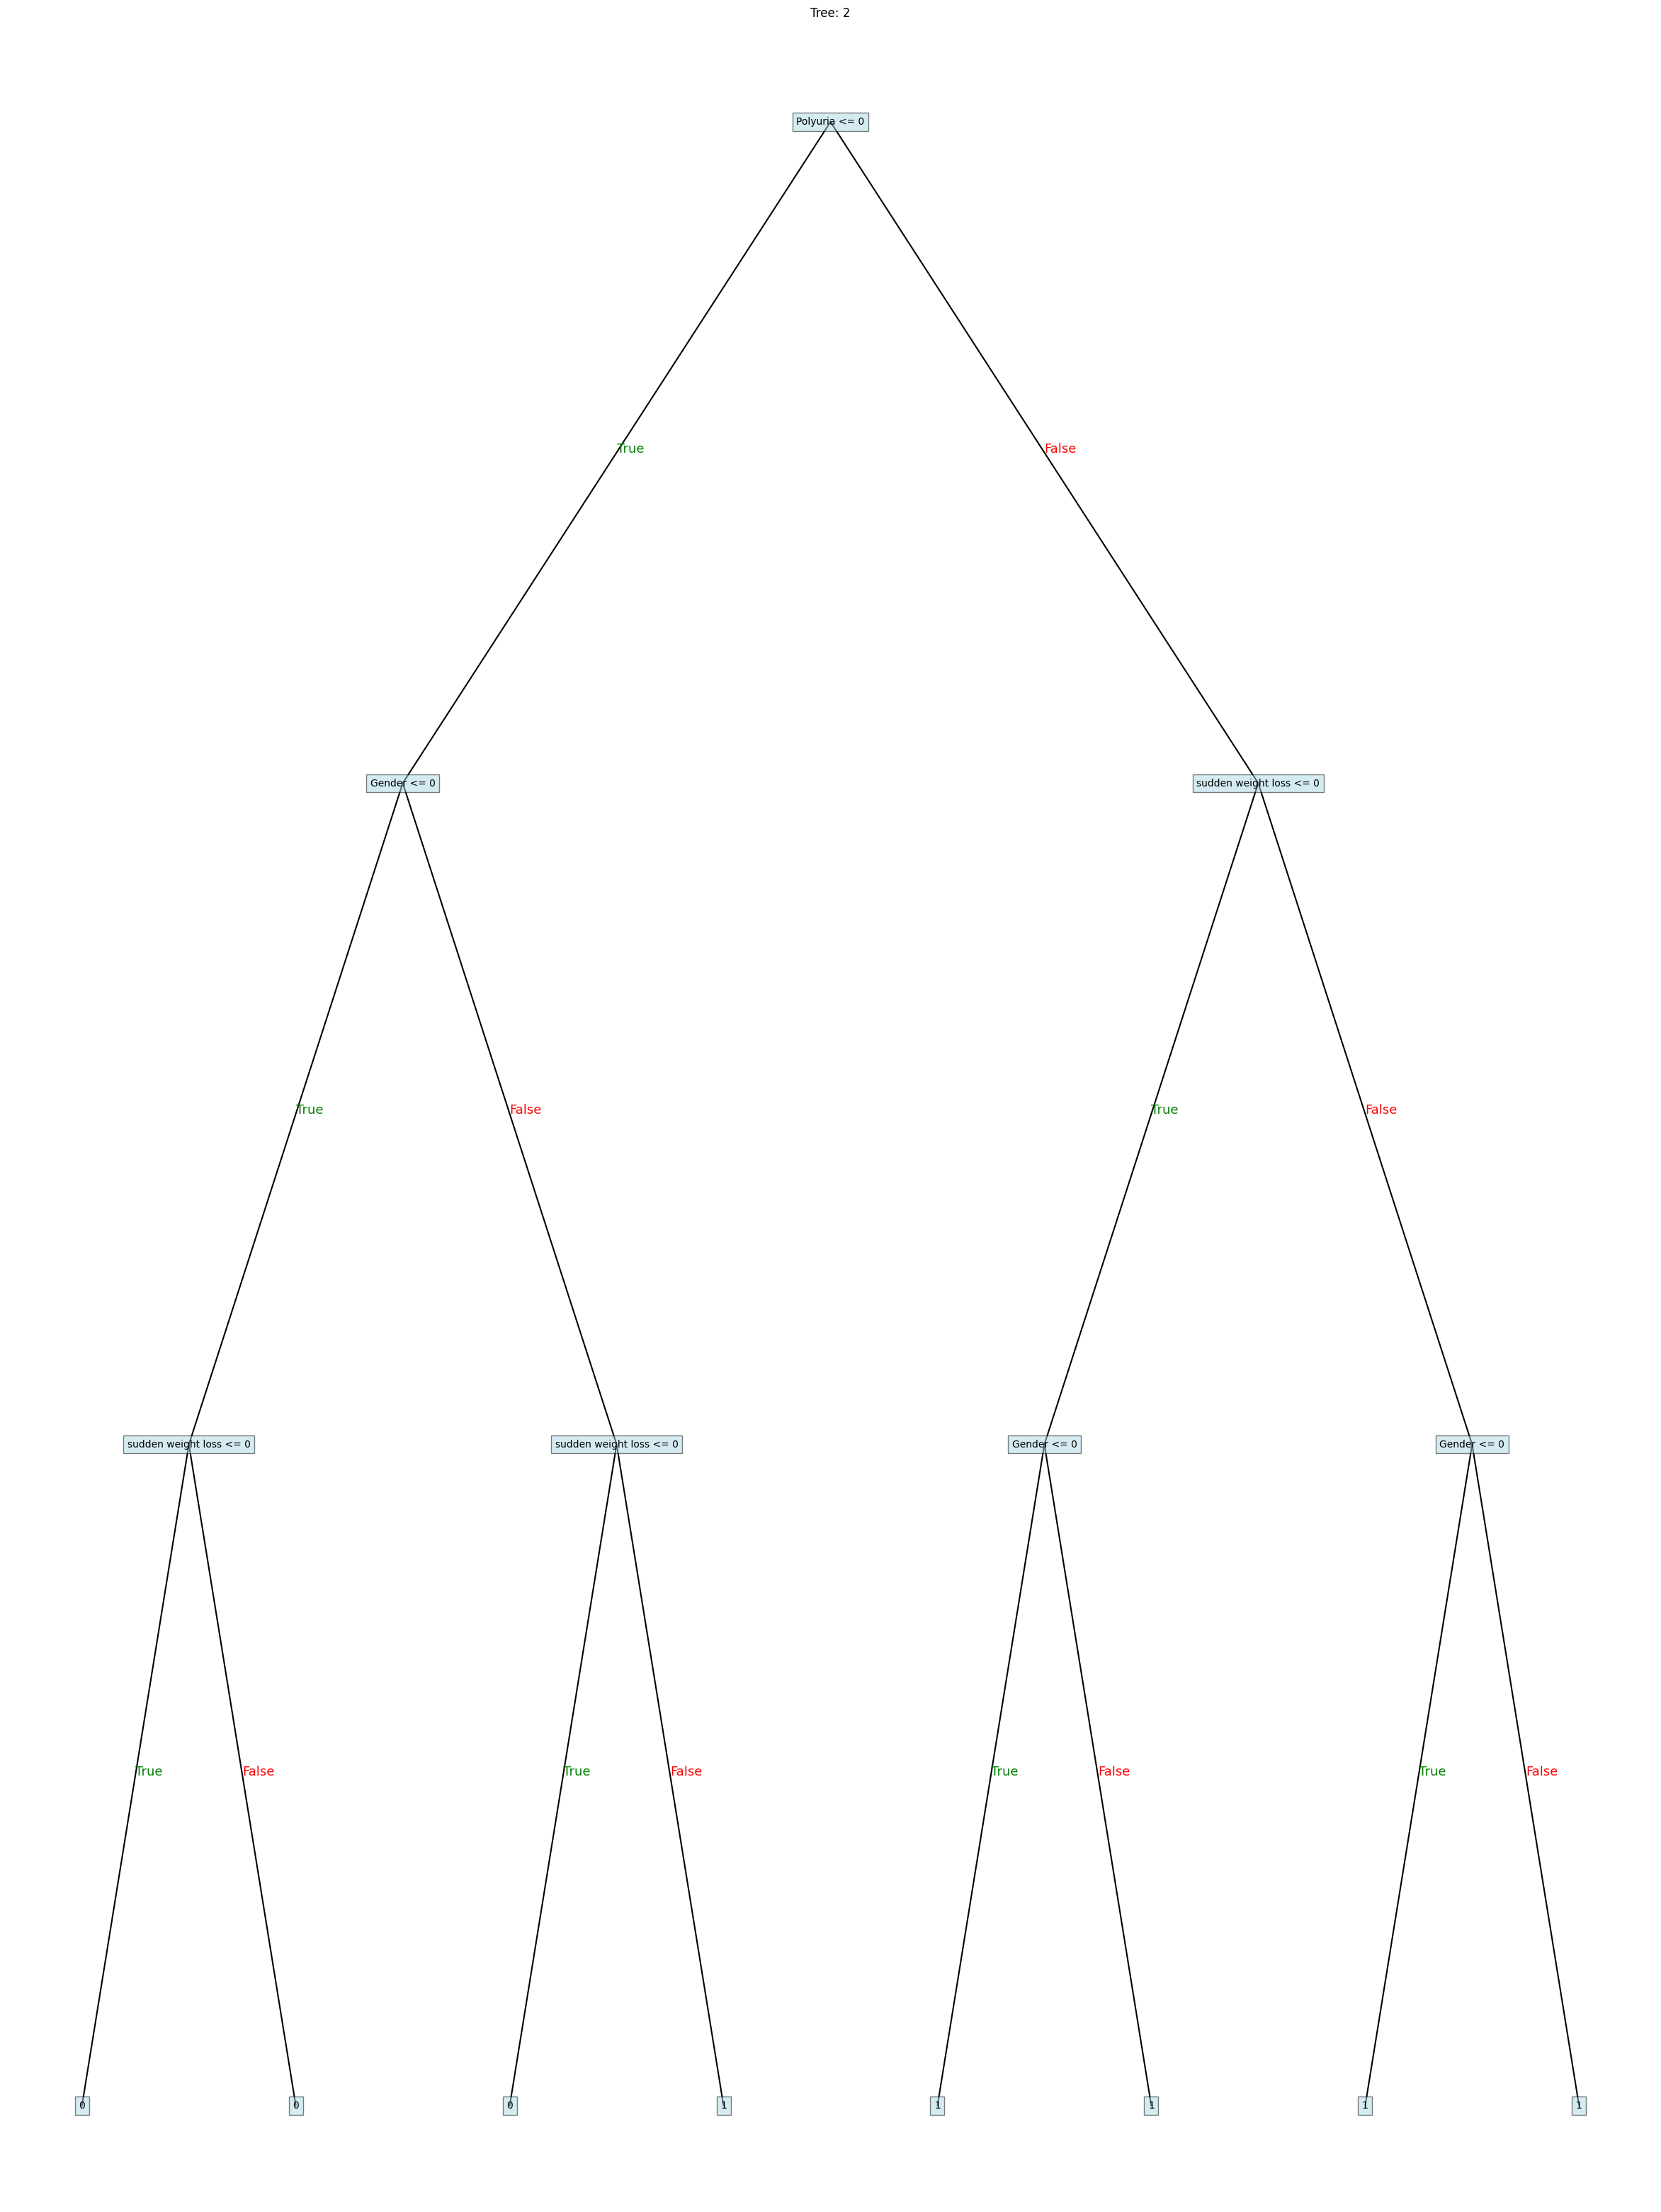

In [ ]:
model_forest.plot_forest(num_trees=2)

### 4. Tracing Path Decision Tree

In [ ]:
X_input = [[0,0,0,1]]
model_tree.predict_with_trace(X_input)


Sample: 1
Polyuria <= 0 Left
  sudden weight loss <= 0 Left
    Gender <= 0 Left
      partial paresis <= 0 Right
        ==> Predict: 0


array([0])

### 5. Tracing Path Random Forest

In [ ]:
X_input = [[0,0,1,0]]
model_forest.predict_with_trace(X_input)


Sample: 1

Tree: 1
Gender <= 0 Left
  Polyuria <= 0 Left
    sudden weight loss <= 0 Left
      ==> Predict: 0

Tree: 2
Polyuria <= 0 Right
  sudden weight loss <= 0 Left
    Gender <= 0 Left
      ==> Predict: 1

Tree: 3
Gender <= 0 Right
  sudden weight loss <= 0 Left
    Polyuria <= 0 Left
      ==> Predict: 1

Tree: 4
Gender <= 0 Left
  Polyuria <= 0 Right
    sudden weight loss <= 0 Left
      ==> Predict: 1

Tree: 5
sudden weight loss <= 0 Left
  Gender <= 0 Right
    Polyuria <= 0 Left
      ==> Predict: 1

Tree: 6
Gender <= 0 Left
  sudden weight loss <= 0 Right
    Polyuria <= 0 Left
      ==> Predict: 1

Tree: 7
Polyuria <= 0 Left
  Gender <= 0 Right
    sudden weight loss <= 0 Left
      ==> Predict: 1

Tree: 8
Gender <= 0 Left
  Polyuria <= 0 Left
    sudden weight loss <= 0 Right
      ==> Predict: 0

Tree: 9
Gender <= 0 Right
  sudden weight loss <= 0 Left
    Polyuria <= 0 Left
      ==> Predict: 1

Tree: 10
Gender <= 0 Left
  Polyuria <= 0 Right
    sudden weight loss 

array([1])

## D. Evaluasi Model

### 1. Confusion Matrix

#### a. Fungsi Confusion Matrix

In [ ]:
def evaluation_metric(y_true, y_pred, average):

    accuracy_array = []
    precision_array = []
    recall_array = []
    f1_score_array = []

    labels = np.unique(y_true)

    for label in labels:

        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        accuracy_array.append(accuracy)
        precision_array.append(precision)
        recall_array.append(recall)
        f1_score_array.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_array)
        precision = np.mean(precision_array)
        recall = np.mean(recall_array)
        f1_score = np.mean(f1_score_array)

    elif average == "micro":
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN = np.sum((y_true != y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

#### b. Evaluasi Model Tree

In [ ]:
accuracy_tree_train, precision_tree_train, recall_tree_train, f1_score_tree_train = evaluation_metric(y_train ,y_pred_tree_train, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Tree Train: {accuracy_tree_train:.2f}%")
print("-----------------------------------------------------------------")
print(f"Presisi Tree Train: {precision_tree_train:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Tree Train: {recall_tree_train:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Tree Train: {f1_score_tree_train:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Tree Train: 86.00%
-----------------------------------------------------------------
Presisi Tree Train: 0.86
-----------------------------------------------------------------
Recall Tree Train: 0.86
-----------------------------------------------------------------
F1 Score Tree Train: 0.86
-----------------------------------------------------------------


In [ ]:
accuracy_tree_test, precision_tree_test, recall_tree_test, f1_score_tree_test = evaluation_metric(y_test ,y_pred_tree_test, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Tree Test: {accuracy_tree_test:.2f}%")
print("-----------------------------------------------------------------")
print(f"Presisi Tree Test: {precision_tree_test:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Tree Test: {recall_tree_test:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Tree Test: {f1_score_tree_test:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Tree Test: 84.31%
-----------------------------------------------------------------
Presisi Tree Test: 0.84
-----------------------------------------------------------------
Recall Tree Test: 0.84
-----------------------------------------------------------------
F1 Score Tree Test: 0.84
-----------------------------------------------------------------


#### c. Evaluasi Model Random Forest

In [ ]:
accuracy_forest_train, precision_forest_train, recall_forest_train, f1_score_forest_train = evaluation_metric(y_train ,y_pred_forest_train, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Random Forest Train: {accuracy_forest_train:.2f}%")
print("-----------------------------------------------------------------")
print(f"Presisi Random Forest Train: {precision_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Random Forest Train: {recall_forest_train:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Random Forest Train: {f1_score_forest_train:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Random Forest Train: 84.50%
-----------------------------------------------------------------
Presisi Random Forest Train: 0.84
-----------------------------------------------------------------
Recall Random Forest Train: 0.84
-----------------------------------------------------------------
F1 Score Random Forest Train: 0.84
-----------------------------------------------------------------


In [ ]:
accuracy_forest_test, precision_forest_test, recall_forest_test, f1_score_forest_test = evaluation_metric(y_test ,y_pred_forest_test, average='micro')

print("-----------------------------------------------------------------")
print(f"Akurasi Random Forest Test: {accuracy_forest_test:.2f}%")
print("-----------------------------------------------------------------")
print(f"Presisi Random Forest Test: {precision_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"Recall Random Forest Test: {recall_forest_test:.2f}")
print("-----------------------------------------------------------------")
print(f"F1 Score Random Forest Test: {f1_score_forest_test:.2f}")
print("-----------------------------------------------------------------")

-----------------------------------------------------------------
Akurasi Random Forest Test: 74.51%
-----------------------------------------------------------------
Presisi Random Forest Test: 0.75
-----------------------------------------------------------------
Recall Random Forest Test: 0.75
-----------------------------------------------------------------
F1 Score Random Forest Test: 0.75
-----------------------------------------------------------------


### 2. K-Fold Cross Validation

#### a. Fungsi K-Fold

In [ ]:
def stratified_k_fold(X, y, model, k = 7):

    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        train_idx = np.hstack([[j] for j in range(k) if j != i])
        test_idx = np.array(folds[i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy, _, _, _ = evaluation_metric(y_test, y_pred, average='micro')
        accuracies.append(accuracy)

        print(f"Fold: {i + 1} | Accuracy: {accuracy}")
    
    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"Average Accuracy Between Folds: {avg_acc}")
    print(f"Total Standard Deviation: {std_dev}")

    return avg_acc, std_dev

#### b. Validation untuk Decision Tree

In [ ]:
k_fold_tree_train = stratified_k_fold(X_test, y_test, model_tree)

Fold: 1 | Accuracy: 62.5
Fold: 2 | Accuracy: 62.5
Fold: 3 | Accuracy: 71.42857142857143
Fold: 4 | Accuracy: 71.42857142857143
Fold: 5 | Accuracy: 71.42857142857143
Fold: 6 | Accuracy: 71.42857142857143
Fold: 7 | Accuracy: 71.42857142857143
Average Accuracy Between Folds: 68.87755102040818
Total Standard Deviation: 4.033517423684159


#### c. Validation untuk Random Forest

In [ ]:
k_fold_tree_train = stratified_k_fold(X_test, y_test, model_forest)

Fold: 1 | Accuracy: 62.5
Fold: 2 | Accuracy: 62.5
Fold: 3 | Accuracy: 71.42857142857143
Fold: 4 | Accuracy: 71.42857142857143
Fold: 5 | Accuracy: 71.42857142857143
Fold: 6 | Accuracy: 71.42857142857143
Fold: 7 | Accuracy: 71.42857142857143
Average Accuracy Between Folds: 68.87755102040818
Total Standard Deviation: 4.033517423684159


# **IV. Kesimpulan**

Setelah melalui cleaning, encoding, modelling, evaluation kami dapat menarik beberapa kesimpulan:

1. Overall model sudah bagus untuk memprediksi Pasien yang benar benar mengidap penyakit diabetes

2. Model belum siap ketika diberikan data baru karena jumlah data yang hanya ratusan

3. Gejala yang paling menentukan apakah suatu pasien mengidap diabetes atau tidak adalah 
- "Polyuria" yang berarti keseringan buang air kecil terutama pada malam hari 
- "Gender" yang berarti pasien dengan kelamin perempuan lebih rentan terhadap penyakit diabetes 
- "sudden weight loss" jika pasien mengalami penurunan berat badan yang drastis
- "partial paresis" ketika suatu pasien mengalami penurunan bahkan kehilangan fungsi suatu otot 



# **V. Graphical User Interface**

In [ ]:
# palette warna
black_color = "#000000"
white_color = "#ffffff"
base_color = "#603448"

In [ ]:
import tkinter as tk
from tkinter import messagebox

def predict_gui():
    try:
        map_output = {1: "Pasien Terjangkit Diabetes", 2: "Pasien Tidak Terjangkit Diabetes",}
        input_polyuria = float(entry_polyuria.get())
        input_gender = float(entry_gender.get())
        input_weight = float(entry_weightloss.get())
        input_partial = float(entry_paresis.get())

        if input_polyuria > 1 or input_polyuria < 0:
            messagebox.showerror(title="Input Kencing Berlebihan Error", message="Masukkan Format Input Yang Benar! (0 dan 1)")
            
        elif input_gender > 1 or input_gender < 0:
            messagebox.showerror(title="Input Gender Error", message="Masukkan Format Input Yang Benar! (0 dan 1)")

        elif input_weight > 1 or input_weight < 0:
            messagebox.showerror(title="Input Berat Bedan Error", message="Masukkan Format Input Yang Benar! (0 dan 1)")

        elif input_partial > 1 or input_partial < 0 :
            messagebox.showerror(title="Input Kehilangan Fungsi Otot Error", message="Masukkan Format Input Yang Benar! (0 dan 1)")

        else:
            user_array = [[input_polyuria, input_gender, input_weight, input_partial]]
            user_output = model_tree.predict(user_array)
            user_output_mapped = map_output[user_output[0]]
            windows_output.config(text = f"Terjangkit: {user_output_mapped}")

    except ValueError:
        messagebox.showerror(title="Input Error", message="Masukkan Format Input Yang Benar! (0 dan 1)")

def reset():
    windows_output.config(text = f"Terjangkit: -")
    
    entry_gender.delete(0, tk.END)
    entry_paresis.delete(0, tk.END)
    entry_polyuria.delete(0, tk.END)
    entry_weightloss.delete(0, tk.END)

windows = tk.Tk()
windows.geometry("1000x700")
windows.title("Model Decision Tree")
windows.configure(bg=white_color)

header_frame = tk.Frame(windows, bg=base_color)
header_frame.pack(fill="x")
tk.Label(header_frame, text="Prediksi Pasien Terjangkit Diabetes", font=("Arial", 12, "bold"), bg=base_color, fg=white_color).pack(fill="x", pady=10)

main_frame = tk.Frame(windows, bg=white_color)
main_frame.pack(pady=10)
main_frame.grid_propagate()

tk.Label(main_frame, text="Sering Membuang Air Kecil", font=("Arial", 12), bg=white_color, fg=black_color).grid(row=0, column=0, pady=10, sticky="w")
entry_polyuria = tk.Entry(main_frame, highlightcolor=base_color, highlightthickness=2)
entry_polyuria.grid(row=0, column=2, pady=10)

tk.Label(main_frame, text="Jenis Kelamin", font=("Arial", 12), bg=white_color, fg=black_color).grid(row=1, column=0, pady=10, sticky="w")
entry_gender = tk.Entry(main_frame, highlightcolor=base_color, highlightthickness=2)
entry_gender.grid(row=1, column=2, pady=10)

tk.Label(main_frame, text="Penurunan Berat Badan Drastis", font=("Arial", 12), bg=white_color, fg=black_color).grid(row=2, column=0, pady=10, sticky="w")
entry_weightloss = tk.Entry(main_frame, highlightcolor=base_color, highlightthickness=2)
entry_weightloss.grid(row=2, column=2, pady=10)

tk.Label(main_frame, text="Kelumpuhan Ringan", font=("Arial", 12), bg=white_color, fg=black_color).grid(row=3, column=0, pady=10, sticky="w")
entry_paresis = tk.Entry(main_frame, highlightcolor=base_color, highlightthickness=2)
entry_paresis.grid(row=3, column=2, pady=10)

tk.Label(main_frame, text="Note\n0: No/Men, 1: Yes/Woman", font=("Arial", 12), bg=white_color, fg=black_color).grid(row=4, columnspan=6, pady=(50, 10))
tk.Button(main_frame, text="Prediksi", font=("Arial", 12, "bold"), bg=base_color, fg=white_color, width=15, command=predict_gui).grid(row=5, columnspan=6, pady=(10, 10))
tk.Button(main_frame, text="Reset", font=("Arial", 12, "bold"), bg=white_color, fg=base_color, width=15, command=reset).grid(row=6, columnspan=6, pady=0)

windows_output = tk.Label(windows, text="Terjangkit: -", font=("Arial", 12), bg=white_color, fg=base_color)
windows_output.pack(fill="x", pady=10)

footer_frame = tk.Frame(windows, bg=base_color)
footer_frame.pack(fill="x", side="bottom")
tk.Label(footer_frame, text="Copyright @ 2025. Asta Production. All rights reserved.", font=("Arial", 11), bg=base_color, fg=white_color).pack(fill="x", pady=10)

windows.mainloop()


NameError: name 'white_color' is not defined

In [ ]:
import gradio as gr

biner_map = {"Yes" : 1, "No" : 0}
gender_map = {"Male" : 0, "Female" : 1}

def predict_diabetes(gender, polyuria, weight, partial):
    
    user_poly = biner_map[polyuria]
    user_gender = gender_map[gender]
    user_weight = biner_map[weight]
    user_partial = biner_map[partial]

    user_array = np.array([[user_poly, user_gender, user_weight, user_partial]])

    user_predict = model_tree.predict(user_array)
    result = "Positive" if user_predict[0] == 1 else "Negative"
    return result

demo = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Radio(["Male", "Female"], label="Gender"),
        gr.Radio(["No", "Yes"], label="Polyuria"),
        gr.Radio(["No", "Yes"], label="Sudden Weight Loss"),
        gr.Radio(["No", "Yes"], label="Partial Paresis")
    ],
    outputs= gr.Textbox(label="Diabetes Prediction"),
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7866

To create a public link, set `share=True` in `launch()`.
